# Hands-on Task 2: Variational Autoencoder

1. Latent variable 潜在变量，模型用来表示图片内部信息的变量
2. Prior distribution 先验分布，即为潜在变量 z 设定的分布
3. Approximate posterior distribution 近似后验分布，编码器根据输入图片预测的分布，用来近似“哪些潜在变量可能解释这张图片”。
4. Reparameterization 重参数化，通过 重参数化技巧 实现采样，使梯度能够传回编码器。
5. Reconstruction loss 重构损失，衡量解码器输出的图片与原始图片的差异。
6. Kullback–Leibler (KL) divergence
   KL 散度，衡量近似后验分布与先验分布的差异。
7. Evidence lower bound (ELBO) 证据下界，VAE 的优化目标，等于重构损失与 KL 散度之和。

why the objective contains both reconstruction and regularization terms.

因为它既要保留输入的信息（reconstruction），又要让潜在分布适合采样生成新数据(regularization)。

In [2]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
)

torch.manual_seed(47)

1. Implement or adapt a simple VAE

In [3]:
class VAE(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()

        # [B, 1, 28, 28] → [B, 64]
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
        )

        # 分别预测均值和对数方差
        self.fc_mu = nn.Linear(64, latent_dim)#每张图片对应的潜在分布的均值，决定分布中心
        self.fc_logvar = nn.Linear(64, latent_dim)#每张图片对应的潜在分布的对数方差，决定分布的离散程度

        # [B, latent_dim] → [B, 1, 28, 28]
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28)),
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstructed = self.decoder(z)
        return reconstructed, mu, logvar

2. Training

In [ ]:
train_dataset = datasets.MNIST(
    root="/Users/kenny/Research/notebook/research-preparation-federated-clustering/data",
    train=True,
    download=False,
    transform=transforms.ToTensor(),
)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vae = VAE(latent_dim=16).to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-4)

def vae_loss(reconstructed, images, mu, logvar):
    batch_size = images.size(0)

    # 每张图片的像素损失求和，再对图片取平均
    recon_loss = F.binary_cross_entropy(
        reconstructed, images, reduction="sum"
    ) / batch_size

    # 每张图片的潜在维度求和，再对图片取平均
    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    ) / batch_size

    loss = recon_loss + kl_loss
    return loss, recon_loss, kl_loss

In [12]:
epochs = 10

for epoch in range(epochs):
    vae.train()

    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0

    # 标签不参与 VAE 训练
    for images, _ in train_loader:
        images = images.to(device)

        optimizer.zero_grad()

        reconstructed, mu, logvar = vae(images)
        loss, recon_loss, kl_loss = vae_loss(
            reconstructed, images, mu, logvar
        )

        loss.backward()
        optimizer.step()

        # 按图片数量累计，正确处理最后一个较小的批次
        batch_size = images.size(0)
        total_loss += loss.item() * batch_size
        total_recon += recon_loss.item() * batch_size
        total_kl += kl_loss.item() * batch_size

    n = len(train_dataset)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Loss: {total_loss / n:.4f} | "
        f"Recon: {total_recon / n:.4f} | "
        f"KL: {total_kl / n:.4f}"
    )

Epoch 1/10 | Loss: 328.9526 | Recon: 313.9162 | KL: 15.0365
Epoch 2/10 | Loss: 212.9562 | Recon: 206.8373 | KL: 6.1189
Epoch 3/10 | Loss: 203.8245 | Recon: 199.5596 | KL: 4.2649
Epoch 4/10 | Loss: 195.6714 | Recon: 190.9733 | KL: 4.6980
Epoch 5/10 | Loss: 188.9401 | Recon: 183.2364 | KL: 5.7037
Epoch 6/10 | Loss: 184.8491 | Recon: 178.3774 | KL: 6.4717
Epoch 7/10 | Loss: 179.7072 | Recon: 171.6780 | KL: 8.0291
Epoch 8/10 | Loss: 174.7392 | Recon: 165.4012 | KL: 9.3381
Epoch 9/10 | Loss: 168.3047 | Recon: 157.0950 | KL: 11.2098
Epoch 10/10 | Loss: 163.7399 | Recon: 151.7134 | KL: 12.0266


3. Display reconstructed samples

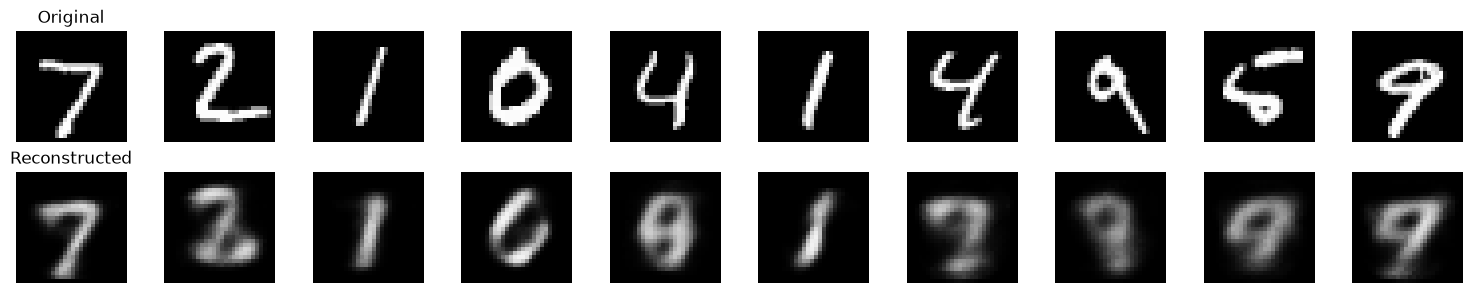

In [13]:
import matplotlib.pyplot as plt

# 加载测试集
test_dataset = datasets.MNIST(
    root="/Users/kenny/Research/notebook/research-preparation-federated-clustering/data",
    train=False,
    download=False,
    transform=transforms.ToTensor(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
)

vae.eval()

# 取 10 张图片
images, _ = next(iter(test_loader))
images = images[:10]

with torch.no_grad():
    reconstructed, _, _ = vae(images.to(device))
    reconstructed = reconstructed.cpu()

fig, axes = plt.subplots(2, 10, figsize=(15, 3))

for i in range(10):
    axes[0, i].imshow(
        images[i, 0].numpy(), cmap="gray", vmin=0, vmax=1
    )
    axes[1, i].imshow(
        reconstructed[i, 0].numpy(), cmap="gray", vmin=0, vmax=1
    )
    axes[0, i].axis("off")
    axes[1, i].axis("off")

axes[0, 0].set_title("Original")
axes[1, 0].set_title("Reconstructed")

plt.tight_layout()
plt.show()

4. Generate new samples from the prior

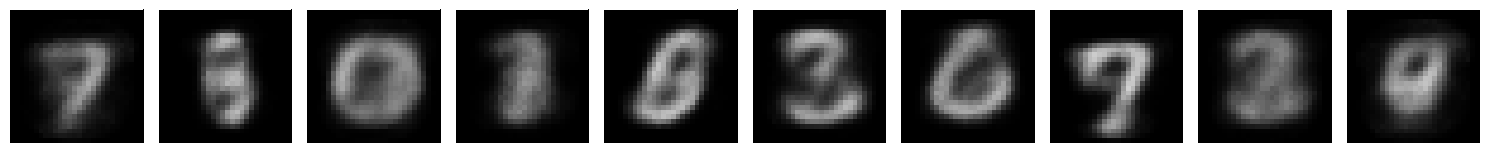

In [14]:
# 获取潜在维度，这里是 16
latent_dim = vae.fc_mu.out_features

with torch.no_grad():
    # 从标准正态先验中采样 10 个潜在向量
    z = torch.randn(10, latent_dim, device=device)

    # [10, 16] → [10, 1, 28, 28]
    generated = vae.decoder(z).cpu()

fig, axes = plt.subplots(1, 10, figsize=(15, 2))

for i in range(10):
    axes[i].imshow(
        generated[i, 0].numpy(), cmap="gray", vmin=0, vmax=1
    )
    axes[i].axis("off")

plt.tight_layout()
plt.show()

5. Use the posterior mean as the representation and pply K-means to the posterior means

In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
)

# 1. 提取每张测试图片的近似后验均值 mu
vae.eval()

latent_batches = []
label_batches = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        # 返回 mu 和 logvar；这里只需要 mu
        # [B, 1, 28, 28] → [B, 16]
        mu, _ = vae.encode(images)

        latent_batches.append(mu.cpu())
        label_batches.append(labels)

# 每一行对应一张图片，特征与标签顺序一致
Z = torch.cat(latent_batches, dim=0).numpy()
y_true = torch.cat(label_batches, dim=0).numpy()

# 2. 在 mu 特征上做 K-means
# MNIST 有 10 个数字类别，这里预先设置 10 个簇
kmeans = KMeans(
    n_clusters=10,
    n_init=10,
    random_state=47,
)

# 真实标签不参与聚类
cluster_labels = kmeans.fit_predict(Z)

# 3. 评价聚类结果
ari = adjusted_rand_score(y_true, cluster_labels)
nmi = normalized_mutual_info_score(y_true, cluster_labels)

# 使用特征和预测簇标签，计算全部测试图片的轮廓系数
silhouette = silhouette_score(Z, cluster_labels)

print(f"ARI: {ari:.4f}")
print(f"NMI: {nmi:.4f}")
print(f"Silhouette score: {silhouette:.4f}")

ARI: 0.3835
NMI: 0.5184
Silhouette score: 0.2065


6. Compare with AE latent representation

In [10]:
import torch
from torch import nn
import torch.nn.functional as F
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
)


# 1. 构建 AE
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()

        # 直接输出潜在向量，不预测分布、不进行采样
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28)),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


# 2. 训练 AE
torch.manual_seed(47)

# 与当前 VAE 使用相同的潜在维度
ae = Autoencoder(
    latent_dim=vae.fc_mu.out_features
).to(device)

ae_optimizer = torch.optim.Adam(ae.parameters(), lr=1e-4)
ae_epochs = epochs

for epoch in range(ae_epochs):
    ae.train()
    total_loss = 0.0

    for images, _ in train_loader:
        images = images.to(device)
        ae_optimizer.zero_grad()

        reconstructed = ae(images)

        # 与 VAE 重建项使用相同的计算方式，AE 没有 KL 项
        loss = F.binary_cross_entropy(
            reconstructed, images, reduction="sum"
        ) / images.size(0)

        loss.backward()
        ae_optimizer.step()

        total_loss += loss.item() * images.size(0)

    print(
        f"AE Epoch {epoch + 1}/{ae_epochs} | "
        f"Recon: {total_loss / len(train_loader.dataset):.4f}"
    )


# 3. 提取两种模型的特征
ae.eval()
vae.eval()

ae_batches = []
vae_batches = []
label_batches = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        # AE：编码器直接输出的潜在向量
        z_ae = ae.encoder(images)

        # VAE：近似后验均值
        mu_vae, _ = vae.encode(images)

        ae_batches.append(z_ae.cpu())
        vae_batches.append(mu_vae.cpu())
        label_batches.append(labels)

# 两种表示对应同一批图片，标签顺序也一致
Z_ae = torch.cat(ae_batches, dim=0).numpy()
Z_vae = torch.cat(vae_batches, dim=0).numpy()
y_true = torch.cat(label_batches, dim=0).numpy()

# 4. 用相同的 K-means 设置比较
print(f"{'Method':<8} {'ARI':>10} {'NMI':>10} {'Silhouette':>12}")

for name, features in [("AE", Z_ae), ("VAE", Z_vae)]:
    kmeans = KMeans(
        n_clusters=10,
        n_init=10,
        random_state=47,
    )

    # 标签不参与聚类，只用于之后的评价
    labels_pred = kmeans.fit_predict(features)

    ari = adjusted_rand_score(y_true, labels_pred)
    nmi = normalized_mutual_info_score(y_true, labels_pred)
    sil = silhouette_score(features, labels_pred)

    print(
        f"{name:<8} {ari:>10.4f} "
        f"{nmi:>10.4f} {sil:>12.4f}"
    )

AE Epoch 1/10 | Recon: 320.2064
AE Epoch 2/10 | Recon: 207.7298
AE Epoch 3/10 | Recon: 198.7816
AE Epoch 4/10 | Recon: 185.7706
AE Epoch 5/10 | Recon: 163.7623
AE Epoch 6/10 | Recon: 149.7443
AE Epoch 7/10 | Recon: 141.1347
AE Epoch 8/10 | Recon: 135.1080
AE Epoch 9/10 | Recon: 129.4588
AE Epoch 10/10 | Recon: 124.8268
Method          ARI        NMI   Silhouette
AE           0.2270     0.3838       0.1999
VAE          0.3835     0.5184       0.2065
